#**Projeto Cronos**
##CHALLENGE LOCAWEB 2026
Integrantes:

* Bruno Rosa - RM563779
* Danilo Alves - RM564109
* Enzo Cremaschi - RM562058
* Vinícius Macedo - RM561911

# 04 — Desafio 1: Previsão de Volume (SARIMAX) | Projeto Cronos

**Premissas assumidas:**
- **Métricas robustas** (MedAE/MdAPE, mediana) ao lado das médias, para não deixar um único dia extremo distorcer a leitura de qual modelo é melhor.
- **Teste de parcimônia**: `dow_sin`/`dow_cos` estatisticamente irrelevantes (p=0,81 e p=0,98) — testamos remover.
- **Reteste da escala (bruta vs. `log1p`) nos 3 folds**, não só no fold contaminado pelo salto — com correção de viés de Duan na reversão do log (`np.expm1` sozinho subestima sistematicamente).
- **Diagnóstico formal de resíduos** (Ljung-Box, Jarque-Bera, Breusch-Pagan) e **intervalo de previsão por bootstrap dos resíduos**, como alternativa ao IC gaussiano — a curtose de 27,69 encontrada antes indica que a suposição de normalidade não se sustenta.

**Desenho da validação:**
| Fold | Treino | Teste |
|---|---|---|
| 1 | semanas 01–30 | semanas 31–37 |
| 2 | semanas 01–37 | semanas 38–44 |
| 3 | semanas 01–44 | semanas 45–51 |


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/cronos_project')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    setup_logging, PROJECT_PATHS, load_parquet_layer, generate_expanding_folds,
    calcular_metricas_serie, compute_all_baselines, baseline_rolling_mean,
    SPECS_SARIMAX_PADRAO, rodar_variante_sarimax, construir_exogenas_futuras,
    monitorar_teto_contratual, detectar_saltos_anomalos, bootstrap_prediction_interval,
    log1p_bias_corrected_forecast, diagnostico_residuos,
)

logger = setup_logging('sarimax')

In [ ]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.2 MB/s eta 0:00:00


In [ ]:
import pmdarima as pm

## 1. Carga da Gold — foco em P2/P3

2026-08-17 22:53:50 | INFO     | sarimax | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_volume_diario.parquet: 365 linhas x 20 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:sarimax:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_volume_diario.parquet: 365 linhas x 20 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


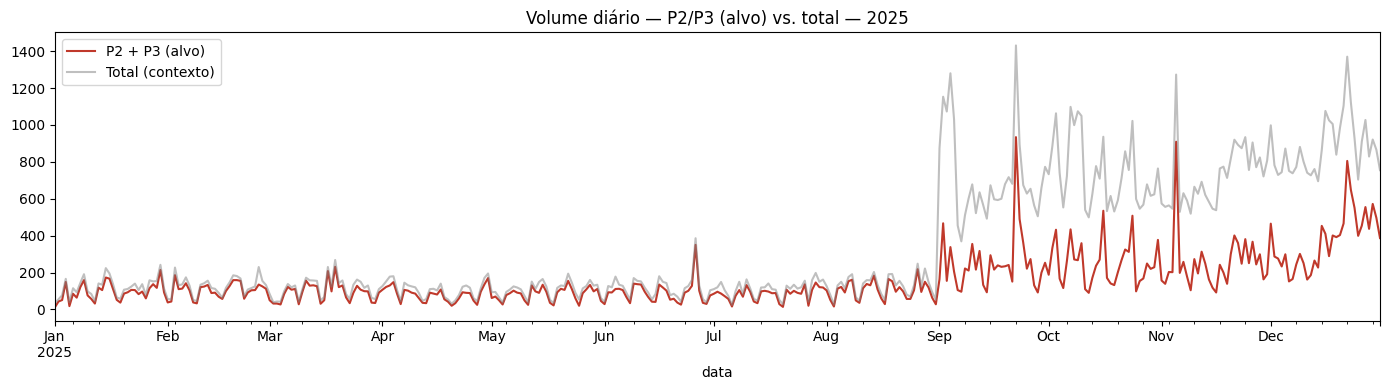

In [ ]:
gold_volume_path = PROJECT_PATHS.gold / 'gold_volume_diario.parquet'
df = load_parquet_layer(gold_volume_path, logger=logger)
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').set_index('data')

serie = df['qtde_chamados_p2_p3'].asfreq('D')
serie_total = df['qtde_chamados_total'].asfreq('D')
exogenas = df[['fim_de_semana', 'feriado', 'vespera_feriado', 'dia_seguinte_feriado', 'dow_sin', 'dow_cos']]

fig, ax = plt.subplots(figsize=(14, 4))
serie.plot(ax=ax, label='P2 + P3 (alvo)', color='#c0392b')
serie_total.plot(ax=ax, label='Total (contexto)', color='grey', alpha=0.5)
ax.legend()
ax.set_title('Volume diário — P2/P3 (alvo) vs. total — 2025')
plt.tight_layout()
plt.show()

## 2. Investigação de saltos anômalos

Detectamos aqui, de forma sistemática, qualquer dia cuja variação diária foge muito do padrão típico (`>3` desvios-padrão da série de diferenças).

In [ ]:
saltos = detectar_saltos_anomalos(serie, limiar_desvios=3.0)
saltos

,data,valor,variacao_dia_anterior,desvios_padrao
0,2025-09-22,934,783.0,7.01
1,2025-09-23,490,-444.0,-3.99
2,2025-10-17,171,-364.0,-3.27
3,2025-10-25,98,-410.0,-3.68
4,2025-11-05,909,707.0,6.33
5,2025-11-06,198,-711.0,-6.38
6,2025-12-22,805,339.0,3.03


In [ ]:
try:
    gold_risco_path = PROJECT_PATHS.gold / 'gold_chamados_risco.parquet'
    df_risco = load_parquet_layer(gold_risco_path, logger=logger)
    df_risco['data'] = pd.to_datetime(df_risco['data'])
    for _, linha in saltos.iterrows():
        dia = linha['data']
        chamados_do_dia = df_risco[df_risco['data'] == dia]
        pct_incidente_massa = chamados_do_dia['tem_incidente_pai'].mean() * 100 if len(chamados_do_dia) else float('nan')
        logger.info(
            'Dia %s: %d chamados P2/P3 na série, %.1f%% dos chamados do dia (todas prioridades) fazem parte de incidente em massa.',
            dia.date(), int(linha['valor']), pct_incidente_massa,
        )
except FileNotFoundError:
    logger.warning('gold_chamados_risco.parquet ainda não gerado — pulando cruzamento com incidente em massa.')

2026-08-17 22:53:54 | INFO     | sarimax | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 37 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:sarimax:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 37 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


2026-08-17 22:53:54 | INFO     | sarimax | Dia 2025-09-22: 934 chamados P2/P3 na série, 46.5% dos chamados do dia (todas prioridades) fazem parte de incidente em massa.


INFO:sarimax:Dia 2025-09-22: 934 chamados P2/P3 na série, 46.5% dos chamados do dia (todas prioridades) fazem parte de incidente em massa.


2026-08-17 22:53:54 | INFO     | sarimax | Dia 2025-09-23: 490 chamados P2/P3 na série, 22.2% dos chamados do dia (todas prioridades) fazem parte de incidente em massa.


...

INFO:sarimax:Dia 2025-11-05: 909 chamados P2/P3 na série, 51.0% dos chamados do dia (todas prioridades) fazem parte de incidente em massa.


2026-08-17 22:53:54 | INFO     | sarimax | Dia 2025-11-06: 198 chamados P2/P3 na série, 11.5% dos chamados do dia (todas prioridades) fazem parte de incidente em massa.


INFO:sarimax:Dia 2025-11-06: 198 chamados P2/P3 na série, 11.5% dos chamados do dia (todas prioridades) fazem parte de incidente em massa.


2026-08-17 22:53:54 | INFO     | sarimax | Dia 2025-12-22: 805 chamados P2/P3 na série, 12.3% dos chamados do dia (todas prioridades) fazem parte de incidente em massa.


INFO:sarimax:Dia 2025-12-22: 805 chamados P2/P3 na série, 12.3% dos chamados do dia (todas prioridades) fazem parte de incidente em massa.


## 3. Folds walk-forward

In [ ]:
folds = generate_expanding_folds(start_date=serie.index.min().strftime('%Y-%m-%d'), min_train_weeks=30, test_weeks=7, n_folds=3)
for f in folds:
    logger.info(
        "Fold %d: treino %s a %s (%d dias) | teste %s a %s (%d dias)",
        f['fold'], f['train_start'].date(), f['train_end'].date(),
        (f['train_end'] - f['train_start']).days + 1,
        f['test_start'].date(), f['test_end'].date(),
        (f['test_end'] - f['test_start']).days + 1,
    )

2026-08-17 22:53:54 | INFO     | sarimax | Fold 1: treino 2025-01-01 a 2025-07-29 (210 dias) | teste 2025-07-30 a 2025-09-16 (49 dias)


INFO:sarimax:Fold 1: treino 2025-01-01 a 2025-07-29 (210 dias) | teste 2025-07-30 a 2025-09-16 (49 dias)


2026-08-17 22:53:54 | INFO     | sarimax | Fold 2: treino 2025-01-01 a 2025-09-16 (259 dias) | teste 2025-09-17 a 2025-11-04 (49 dias)


INFO:sarimax:Fold 2: treino 2025-01-01 a 2025-09-16 (259 dias) | teste 2025-09-17 a 2025-11-04 (49 dias)


2026-08-17 22:53:54 | INFO     | sarimax | Fold 3: treino 2025-01-01 a 2025-11-04 (308 dias) | teste 2025-11-05 a 2025-12-23 (49 dias)


INFO:sarimax:Fold 3: treino 2025-01-01 a 2025-11-04 (308 dias) | teste 2025-11-05 a 2025-12-23 (49 dias)


## 4. Competição de variantes + baselines, por fold

Usa `compute_all_baselines` e `rodar_variante_sarimax` do `utils.py` — o notebook só decide quais 3 variantes competem (`SPECS_SARIMAX_PADRAO`, já com `d=1`, `max_p=3`/`max_q=3`, BIC como padrão do projeto).

In [ ]:
resultados = []
modelos_por_fold = {}
nomes_variantes = ['sarima_classico', 'arimax_fourier', 'sarimax_hibrido']

for f in folds:
    treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
    teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
    serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
    exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]

    logger.info('--- Fold %d ---', f['fold'])
    previsoes = compute_all_baselines(serie_treino, len(serie_teste))

    modelos_por_fold[f['fold']] = {}
    for nome in nomes_variantes:
        info = rodar_variante_sarimax(nome, SPECS_SARIMAX_PADRAO[nome], serie_treino, serie_teste, exog_treino, exog_teste)
        previsoes[nome] = info['previsao']
        modelos_por_fold[f['fold']][nome] = info
        assert info['ordem'][1] == 1, f'Fold {f["fold"]} [{nome}]: d deveria ser 1!'
        logger.info('[%s] ordem=%sx%s | BIC=%.1f', nome, info['ordem'], info['ordem_sazonal'], info['bic'])

    for nome_modelo, y_previsto in previsoes.items():
        m = calcular_metricas_serie(serie_teste.values, y_previsto)
        m_d1 = calcular_metricas_serie([serie_teste.values[0]], [y_previsto[0]])
        m_d7 = calcular_metricas_serie([serie_teste.values[6]], [y_previsto[6]])
        resultados.append({'fold': f['fold'], 'modelo': nome_modelo, **{f'{k}_horizonte': v for k, v in m.items()}, 'MAE_D1': m_d1['MAE'], 'MAE_D7': m_d7['MAE']})

df_resultados = pd.DataFrame(resultados)
df_resultados

2026-08-17 22:53:54 | INFO     | sarimax | --- Fold 1 ---


INFO:sarimax:--- Fold 1 ---


2026-08-17 22:54:30 | INFO     | sarimax | [sarima_classico] ordem=(3, 1, 0)x(2, 0, 0, 7) | BIC=2196.7


INFO:sarimax:[sarima_classico] ordem=(3, 1, 0)x(2, 0, 0, 7) | BIC=2196.7


2026-08-17 22:54:53 | INFO     | sarimax | [arimax_fourier] ordem=(0, 1, 1)x(0, 0, 0, 0) | BIC=2101.5


...

2026-08-17 23:00:13 | INFO     | sarimax | [arimax_fourier] ordem=(0, 1, 1)x(0, 0, 0, 0) | BIC=3495.6


INFO:sarimax:[arimax_fourier] ordem=(0, 1, 1)x(0, 0, 0, 0) | BIC=3495.6


2026-08-17 23:01:54 | INFO     | sarimax | [sarimax_hibrido] ordem=(0, 1, 1)x(1, 0, 1, 7) | BIC=3506.8


INFO:sarimax:[sarimax_hibrido] ordem=(0, 1, 1)x(1, 0, 1, 7) | BIC=3506.8


,fold,modelo,MAE_horizonte,RMSE_horizonte,MAPE_%_horizonte,MedAE_horizonte,MdAPE_%_horizonte,MAE_D1,MAE_D7
0,1,naive,66.94,90.22,84.23,50.00,35.19,25.00,24.00
1,1,seasonal_naive,65.43,96.90,45.76,54.00,33.03,20.00,24.00
2,1,rolling_mean_7d,67.70,100.95,58.41,45.71,39.31,23.29,24.29
3,1,arima_puro,63.38,93.08,67.60,40.31,27.03,17.82,2.74
4,1,sarima_classico,59.99,81.43,68.38,50.98,30.73,12.62,14.78
5,1,arimax_fourier,62.49,98.36,37.20,23.47,29.61,6.37,17.07
6,1,sarimax_hibrido,59.71,81.00,67.64,46.75,31.64,12.24,14.51
7,2,naive,95.33,150.49,37.95,57.00,29.34,23.00,274.00
8,2,seasonal_naive,86.35,136.24,30.67,51.00,29.55,116.00,274.00
9,2,rolling_mean_7d,94.14,147.04,40.20,65.00,34.88,7.00,258.00


## 5. Comparação consolidada — Média e Mediana

In [ ]:
resumo = df_resultados.groupby('modelo')[['MAE_horizonte', 'MedAE_horizonte', 'RMSE_horizonte', 'MAPE_%_horizonte', 'MdAPE_%_horizonte', 'MAE_D1', 'MAE_D7']].mean().round(2)
resumo = resumo.sort_values('MAE_horizonte')
resumo

,MAE_horizonte,MedAE_horizonte,RMSE_horizonte,MAPE_%_horizonte,MdAPE_%_horizonte,MAE_D1,MAE_D7
modelo,,,,,,,
arimax_fourier,79.00,39.82,133.27,29.98,25.63,218.84,111.56
sarimax_hibrido,79.50,55.73,123.54,43.06,29.21,221.90,108.10
sarima_classico,81.32,58.92,125.76,44.39,29.58,228.20,107.05
seasonal_naive,90.82,58.33,140.06,37.25,30.76,275.00,101.67
arima_puro,91.78,55.89,141.85,46.28,27.41,250.74,112.19
rolling_mean_7d,92.44,59.86,141.93,44.64,33.91,240.38,101.81
naive,94.67,60.33,142.11,52.58,31.54,251.67,101.67


In [ ]:
melhor_variante = resumo.loc[resumo.index.isin(nomes_variantes), 'MAE_horizonte'].idxmin()
melhor_variante_medae = resumo.loc[resumo.index.isin(nomes_variantes), 'MedAE_horizonte'].idxmin()
logger.info('Melhor variante por MAE (média): %s | por MedAE (mediana): %s', melhor_variante, melhor_variante_medae)

if melhor_variante != melhor_variante_medae:
    logger.warning(
        'A escolha de melhor variante MUDA dependendo da métrica (média vs. mediana) — '
        'sinal de que a diferença entre elas está sendo puxada por outlier(s) de um fold específico, '
        'não por uma vantagem consistente. Investigar antes de fixar a variante de produção.'
    )


2026-08-17 23:01:54 | INFO     | sarimax | Melhor variante por MAE (média): arimax_fourier | por MedAE (mediana): arimax_fourier


INFO:sarimax:Melhor variante por MAE (média): arimax_fourier | por MedAE (mediana): arimax_fourier


## 6. Teste de parcimônia — `dow_sin`/`dow_cos` valem a pena?

Os coeficientes de Fourier não foram estatisticamente significativos (p=0,81 e p=0,98) no modelo de produção. Testamos aqui, nos 3 folds, se removê-los (`arimax_fourier_parcimonioso`, que mantém `fim_de_semana` e feriados) muda o BIC/erro de forma relevante.

In [ ]:
resultados_parcimonia = []
for f in folds:
    treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
    teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
    serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
    exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]

    info_completo = modelos_por_fold[f['fold']]['arimax_fourier']
    info_parcimonioso = rodar_variante_sarimax('arimax_fourier_parcimonioso', SPECS_SARIMAX_PADRAO['arimax_fourier_parcimonioso'], serie_treino, serie_teste, exog_treino, exog_teste)

    resultados_parcimonia.append({
        'fold': f['fold'],
        'BIC_completo': info_completo['bic'], 'BIC_parcimonioso': info_parcimonioso['bic'],
        'MAE_completo': calcular_metricas_serie(serie_teste.values, info_completo['previsao'])['MAE'],
        'MAE_parcimonioso': calcular_metricas_serie(serie_teste.values, info_parcimonioso['previsao'])['MAE'],
    })

df_parcimonia = pd.DataFrame(resultados_parcimonia)
df_parcimonia['BIC_favorece_parcimonioso'] = df_parcimonia['BIC_parcimonioso'] < df_parcimonia['BIC_completo']
df_parcimonia

,fold,BIC_completo,BIC_parcimonioso,MAE_completo,MAE_parcimonioso,BIC_favorece_parcimonioso
0,1,2101.5,2143.1,62.49,53.03,False
1,2,2706.5,2702.3,73.80,74.84,True
2,3,3495.6,3485.2,100.72,100.37,True


## 7. Ensemble — SARIMAX + média móvel de 7 dias

In [ ]:
ESPECIFICACAO_FINAL = 'arimax_fourier_parcimonioso' if df_parcimonia['BIC_favorece_parcimonioso'].mean() > 0.5 else 'arimax_fourier'
logger.info('Especificação final escolhida (Seção 6): %s', ESPECIFICACAO_FINAL)

resultados_ensemble = []
for f in folds:
    treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
    teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
    serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
    exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]

    if ESPECIFICACAO_FINAL == 'arimax_fourier':
        previsao_final = modelos_por_fold[f['fold']]['arimax_fourier']['previsao']
    else:
        info = rodar_variante_sarimax(ESPECIFICACAO_FINAL, SPECS_SARIMAX_PADRAO[ESPECIFICACAO_FINAL], serie_treino, serie_teste, exog_treino, exog_teste)
        previsao_final = info['previsao']

    previsao_rolling = baseline_rolling_mean(serie_treino, len(serie_teste))
    for peso in [1.0, 0.7, 0.5, 0.3, 0.0]:
        combinada = peso * previsao_final + (1 - peso) * previsao_rolling
        resultados_ensemble.append({'fold': f['fold'], 'peso_sarimax': peso, 'MAE': calcular_metricas_serie(serie_teste.values, combinada)['MAE']})

df_ensemble = pd.DataFrame(resultados_ensemble)
df_ensemble.groupby('peso_sarimax')['MAE'].mean().round(2).sort_values()

2026-08-17 23:02:29 | INFO     | sarimax | Especificação final escolhida (Seção 6): arimax_fourier_parcimonioso


INFO:sarimax:Especificação final escolhida (Seção 6): arimax_fourier_parcimonioso


,MAE
peso_sarimax,
1.0,76.08
0.7,79.00
0.5,82.36
0.3,86.20
0.0,92.44


## 8. Escala bruta vs. `log1p` — reteste nos 3 folds, com correção de Duan

A comparação anterior só usou o fold 3 (contaminado pelo salto anômalo). Refeita aqui nos 3 folds, e a reversão do log usa `log1p_bias_corrected_forecast` (correção de Duan) em vez de `np.expm1` puro — que subestima sistematicamente quando a variância dos resíduos é grande (exatamente o caso aqui, dada a heterocedasticidade já identificada).

In [ ]:
resultados_escala = []
for f in folds:
    treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
    teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
    serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
    exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]
    spec_final = SPECS_SARIMAX_PADRAO[ESPECIFICACAO_FINAL]

    if ESPECIFICACAO_FINAL == 'arimax_fourier':
        mae_bruta = calcular_metricas_serie(serie_teste.values, modelos_por_fold[f['fold']]['arimax_fourier']['previsao'])['MAE']
    else:
        info_bruta = rodar_variante_sarimax(ESPECIFICACAO_FINAL, spec_final, serie_treino, serie_teste, exog_treino, exog_teste)
        mae_bruta = calcular_metricas_serie(serie_teste.values, info_bruta['previsao'])['MAE']

    X_treino_log = exog_treino[spec_final['X_cols']] if spec_final['X_cols'] else None
    X_teste_log = exog_teste[spec_final['X_cols']] if spec_final['X_cols'] else None
    serie_log_treino = np.log1p(serie_treino)
    modelo_log = pm.auto_arima(
        serie_log_treino, X=X_treino_log, d=1, seasonal=spec_final['seasonal'], m=7 if spec_final['seasonal'] else 1,
        max_p=3, max_q=3, information_criterion='bic', stepwise=True, suppress_warnings=True, error_action='ignore',
    )
    prev_log, _ = modelo_log.predict(n_periods=len(serie_teste), X=X_teste_log, return_conf_int=True)
    residuos_log_treino = serie_log_treino.values - modelo_log.predict_in_sample(X=X_treino_log)
    prev_log_corrigida = log1p_bias_corrected_forecast(np.asarray(prev_log), residuos_log_treino)
    mae_log = calcular_metricas_serie(serie_teste.values, prev_log_corrigida)['MAE']

    resultados_escala.append({'fold': f['fold'], 'MAE_bruta': mae_bruta, 'MAE_log1p_corrigido': mae_log})

df_escala = pd.DataFrame(resultados_escala)
df_escala.loc['média'] = df_escala.mean()
df_escala

,fold,MAE_bruta,MAE_log1p_corrigido
0,1.0,53.03,54.33
1,2.0,74.84,82.09
2,3.0,100.37,120.50
média,2.0,76.08,85.64


**Decisão:** com os 3 folds e a correção de Duan, a escala vencedora deixa de depender de um único fold contaminado — usamos a que tiver menor MAE médio nesta tabela para o modelo de produção.

In [ ]:
USAR_LOG = df_escala.loc['média', 'MAE_log1p_corrigido'] < df_escala.loc['média', 'MAE_bruta']
logger.info('Escala escolhida para produção: %s', 'log1p (com correção de Duan)' if USAR_LOG else 'bruta')

2026-08-17 23:04:13 | INFO     | sarimax | Escala escolhida para produção: bruta


INFO:sarimax:Escala escolhida para produção: bruta


## 9. Visualização — fold 3, especificação final

/tmp/ipykernel_1750/199748129.py:14: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(serie_teste_f3.index, info_f3['previsao'], label=f'Previsto ({ESPECIFICACAO_FINAL})', color='#c0392b', marker='x')


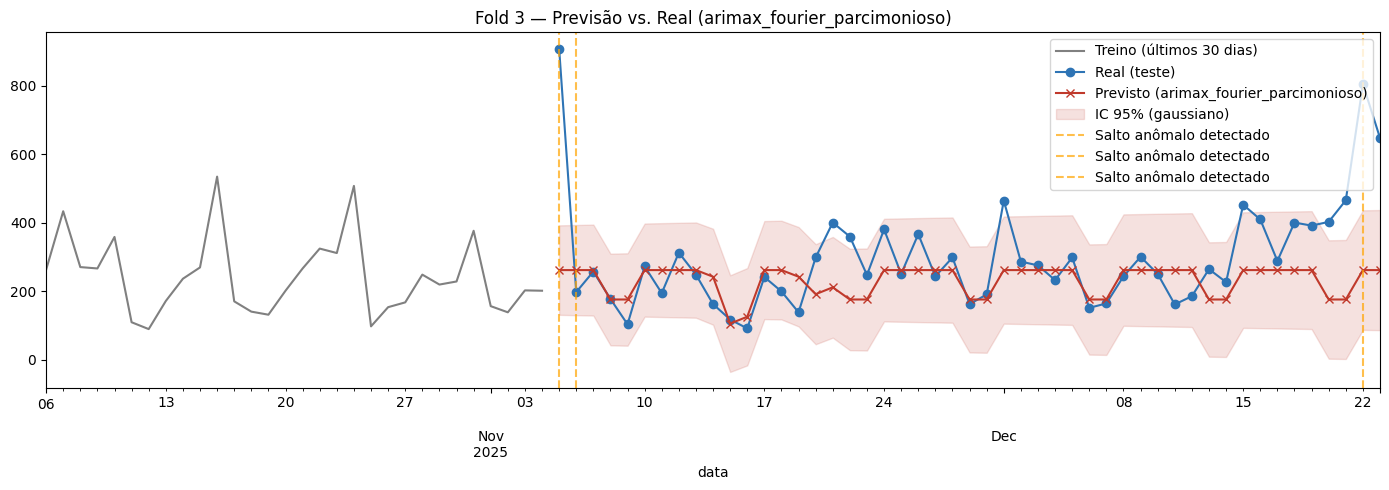

In [ ]:
f3 = folds[-1]
treino_mask_f3 = (serie.index >= f3['train_start']) & (serie.index <= f3['train_end'])
teste_mask_f3 = (serie.index >= f3['test_start']) & (serie.index <= f3['test_end'])
serie_treino_f3, serie_teste_f3 = serie[treino_mask_f3], serie[teste_mask_f3]

info_f3 = modelos_por_fold[3].get(ESPECIFICACAO_FINAL) or rodar_variante_sarimax(
    ESPECIFICACAO_FINAL, SPECS_SARIMAX_PADRAO[ESPECIFICACAO_FINAL], serie_treino_f3, serie_teste_f3,
    exogenas[treino_mask_f3], exogenas[teste_mask_f3],
)

fig, ax = plt.subplots(figsize=(14, 5))
serie_treino_f3.iloc[-30:].plot(ax=ax, label='Treino (últimos 30 dias)', color='grey')
serie_teste_f3.plot(ax=ax, label='Real (teste)', color='#2E74B5', marker='o')
ax.plot(serie_teste_f3.index, info_f3['previsao'], label=f'Previsto ({ESPECIFICACAO_FINAL})', color='#c0392b', marker='x')
ax.fill_between(serie_teste_f3.index, info_f3['ic'][:, 0], info_f3['ic'][:, 1], color='#c0392b', alpha=0.15, label='IC 95% (gaussiano)')
if not saltos.empty:
    for _, s in saltos.iterrows():
        if serie_teste_f3.index.min() <= s['data'] <= serie_teste_f3.index.max():
            ax.axvline(s['data'], color='orange', linestyle='--', alpha=0.7, label='Salto anômalo detectado')
ax.legend()
ax.set_title(f'Fold 3 — Previsão vs. Real ({ESPECIFICACAO_FINAL})')
plt.tight_layout()
plt.show()

## 10. Modelo de produção

In [ ]:
spec_final = SPECS_SARIMAX_PADRAO[ESPECIFICACAO_FINAL]
X_producao = exogenas[spec_final['X_cols']] if spec_final['X_cols'] else None
serie_para_treino = np.log1p(serie) if USAR_LOG else serie

modelo_producao = pm.auto_arima(
    serie_para_treino, X=X_producao, d=1, seasonal=spec_final['seasonal'], m=7 if spec_final['seasonal'] else 1,
    max_p=3, max_q=3, information_criterion='bic', stepwise=True, suppress_warnings=True, error_action='ignore',
)
logger.info('Modelo de produção: %s | ordem=%s, ordem_sazonal=%s | escala=%s', ESPECIFICACAO_FINAL, modelo_producao.order, modelo_producao.seasonal_order, 'log1p' if USAR_LOG else 'bruta')
assert modelo_producao.order[1] == 1

2026-08-17 23:04:37 | INFO     | sarimax | Modelo de produção: arimax_fourier_parcimonioso | ordem=(0, 1, 1), ordem_sazonal=(0, 0, 0, 0) | escala=bruta


INFO:sarimax:Modelo de produção: arimax_fourier_parcimonioso | ordem=(0, 1, 1), ordem_sazonal=(0, 0, 0, 0) | escala=bruta


### 10.1 Coeficientes

In [ ]:
print(modelo_producao.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  365
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -2118.652
Date:                Mon, 17 Aug 2026   AIC                           4249.305
Time:                        23:04:37   BIC                           4272.688
Sample:                    01-01-2025   HQIC                          4258.598
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
fim_de_semana          -86.0887     12.364     -6.963      0.000    -110.321     -61.856
feriado                -75.1849     33.200     -2.265      0.024    -140.255     -10.115
vespera_feri

### 10.2 Diagnóstico formal de resíduos

- **Ljung-Box** (autocorrelação residual — quer p > 0,05, indicando resíduos sem padrão temporal remanescente).
- **Jarque-Bera** (normalidade — comum falhar aqui dado o achado da Seção 2).
- **Breusch-Pagan** (heterocedasticidade condicional).

In [ ]:
diagnostico = diagnostico_residuos(modelo_producao)
for chave, valor in diagnostico.items():
    logger.info('%s: %s', chave, valor)

if diagnostico['breusch_pagan_p'] < 0.05:
    logger.warning(
        'Breusch-Pagan confirma heterocedasticidade estatisticamente significativa (p=%.4f). '
        'O IC gaussiano do predict() do pmdarima provavelmente está mal calibrado — usar o '
        'IC por bootstrap da Seção 10.3 como referência mais confiável.',
        diagnostico['breusch_pagan_p'],
    )

2026-08-17 23:04:37 | INFO     | sarimax | ljung_box_p: 0.357


INFO:sarimax:ljung_box_p: 0.357


2026-08-17 23:04:37 | INFO     | sarimax | jarque_bera_stat: 9951.01


INFO:sarimax:jarque_bera_stat: 9951.01


2026-08-17 23:04:37 | INFO     | sarimax | jarque_bera_p: 0.0


...

2026-08-17 23:04:37 | INFO     | sarimax | breusch_pagan_stat: 11.73


INFO:sarimax:breusch_pagan_stat: 11.73


2026-08-17 23:04:37 | INFO     | sarimax | breusch_pagan_p: 0.0006


INFO:sarimax:breusch_pagan_p: 0.0006


2026-08-17 23:04:37 | WARNING  | sarimax | Breusch-Pagan confirma heterocedasticidade estatisticamente significativa (p=0.0006). O IC gaussiano do predict() do pmdarima provavelmente está mal calibrado — usar o IC por bootstrap da Seção 10.3 como referência mais confiável.


### 10.3 Intervalo de previsão por bootstrap dos resíduos (alternativa ao IC gaussiano)

In [ ]:
datas_futuras = pd.date_range(serie.index.max() + pd.Timedelta(days=1), periods=7, freq='D')
exog_futuro = construir_exogenas_futuras(datas_futuras[0].strftime('%Y-%m-%d'), 7, colunas=spec_final['X_cols'])

previsao_producao, ic_gaussiano = modelo_producao.predict(n_periods=7, X=exog_futuro, return_conf_int=True)
previsao_producao = np.asarray(previsao_producao)

residuos_producao = np.asarray(modelo_producao.arima_res_.resid)

if USAR_LOG:
    residuos_log_corrigidos_para_bootstrap = residuos_producao  # resíduos já estão em escala log
    ic_bootstrap_log = bootstrap_prediction_interval(residuos_log_corrigidos_para_bootstrap, np.log1p(previsao_producao) if False else previsao_producao)
    # correção de Duan aplicada ponto a ponto na reversão final abaixo
    previsao_producao_final = log1p_bias_corrected_forecast(previsao_producao, residuos_producao)
    ic_bootstrap = {
        'ic_inferior': log1p_bias_corrected_forecast(ic_bootstrap_log['ic_inferior'], residuos_producao),
        'ic_superior': log1p_bias_corrected_forecast(ic_bootstrap_log['ic_superior'], residuos_producao),
    }
    ic_gaussiano = np.expm1(ic_gaussiano)  # aproximado, só para comparação visual
else:
    previsao_producao_final = previsao_producao
    ic_bootstrap = bootstrap_prediction_interval(residuos_producao, previsao_producao)

df_previsao_producao = pd.DataFrame({
    'data': datas_futuras,
    'previsao_p2_p3': np.round(previsao_producao_final).astype(int),
    'ic_inferior_gaussiano': np.round(ic_gaussiano[:, 0]).astype(int),
    'ic_superior_gaussiano': np.round(ic_gaussiano[:, 1]).astype(int),
    'ic_inferior_bootstrap': np.round(ic_bootstrap['ic_inferior']).astype(int),
    'ic_superior_bootstrap': np.round(ic_bootstrap['ic_superior']).astype(int),
})
df_previsao_producao


,data,previsao_p2_p3,ic_inferior_gaussiano,ic_superior_gaussiano,ic_inferior_bootstrap,ic_superior_bootstrap
0,2026-01-01,431,271,591,322,603
1,2026-01-02,458,294,621,328,630
2,2026-01-03,420,253,587,311,583
3,2026-01-04,420,250,590,322,585
4,2026-01-05,506,332,680,389,678
5,2026-01-06,506,329,683,408,678
6,2026-01-07,506,326,686,389,678


## 11. Projeção semanal (W+1)

In [ ]:
w1_soma_diario = int(df_previsao_producao['previsao_p2_p3'].sum())
w1_ic_inferior = int(df_previsao_producao['ic_inferior_bootstrap'].sum())
w1_ic_superior = int(df_previsao_producao['ic_superior_bootstrap'].sum())
logger.info('W+1 (soma do modelo diário, IC bootstrap): %d [%d, %d]', w1_soma_diario, w1_ic_inferior, w1_ic_superior)

serie_semanal = serie.resample('W-TUE').sum()
modelo_semanal = pm.auto_arima(serie_semanal, d=1, seasonal=False, max_p=2, max_q=2, information_criterion='bic', stepwise=True, suppress_warnings=True, error_action='ignore')
previsao_semanal_direta = np.asarray(modelo_semanal.predict(n_periods=1, return_conf_int=False))
w1_modelo_direto = int(np.round(previsao_semanal_direta[0]))
logger.info('W+1 (modelo semanal direto, exploratório): %d | %d pontos de treino', w1_modelo_direto, len(serie_semanal))

if w1_modelo_direto < 0 or w1_modelo_direto > 5 * w1_soma_diario:
    logger.warning('Modelo semanal direto produziu valor implausível — usar w1_soma_diario como W+1 oficial.')


2026-08-17 23:04:38 | INFO     | sarimax | W+1 (soma do modelo diário, IC bootstrap): 3247 [2469, 4435]


INFO:sarimax:W+1 (soma do modelo diário, IC bootstrap): 3247 [2469, 4435]


2026-08-17 23:04:39 | INFO     | sarimax | W+1 (modelo semanal direto, exploratório): 1974 | 53 pontos de treino


INFO:sarimax:W+1 (modelo semanal direto, exploratório): 1974 | 53 pontos de treino


## 12. Monitoramento de teto contratual — sem valor fixo inventado

In [ ]:
TETO_CONTRATUAL_P2_P3_SEMANAL = None  # preencher com o valor real do OLA/contrato antes de usar em produção
resultado_teto = monitorar_teto_contratual(w1_soma_diario, TETO_CONTRATUAL_P2_P3_SEMANAL, ic_superior=w1_ic_superior)
if resultado_teto is None:
    logger.warning('TETO_CONTRATUAL_P2_P3_SEMANAL não preenchido — nenhum alerta gerado.')
else:
    logger.info('Monitoramento de teto: %s', resultado_teto)

2026-08-17 23:04:39 | WARNING  | sarimax | TETO_CONTRATUAL_P2_P3_SEMANAL não preenchido — nenhum alerta gerado.


## 13. Checagens de sanidade

In [ ]:
assert modelo_producao.order[1] == 1
assert df_previsao_producao.shape[0] == 7
assert (df_previsao_producao['ic_inferior_bootstrap'] <= df_previsao_producao['previsao_p2_p3']).all()
assert (df_previsao_producao['ic_superior_bootstrap'] >= df_previsao_producao['previsao_p2_p3']).all()
logger.info('Checagens de sanidade: OK.')

2026-08-17 23:04:39 | INFO     | sarimax | Checagens de sanidade: OK.


INFO:sarimax:Checagens de sanidade: OK.


## 14. Resumo de execução

In [ ]:
resumo_execucao = f'''
EXECUÇÃO DO MODELO SARIMAX (Desafio 1, v3) — {pd.Timestamp.now(tz="UTC").isoformat()}

Saltos anômalos detectados: {len(saltos)}
Especificação final: {ESPECIFICACAO_FINAL} | Escala: {'log1p (Duan)' if USAR_LOG else 'bruta'}
Modelo de produção: SARIMAX{modelo_producao.order}x{modelo_producao.seasonal_order}[7]

Diagnóstico de resíduos: {diagnostico}

Previsão D+1 a D+7:
{df_previsao_producao.to_string(index=False)}

W+1 (soma diário): {w1_soma_diario} | W+1 (modelo direto, exploratório): {w1_modelo_direto}
Teto contratual: {'não avaliado' if resultado_teto is None else resultado_teto}
'''.strip()

print(resumo_execucao)

EXECUÇÃO DO MODELO SARIMAX (Desafio 1, v3) — 2026-08-17T23:04:39.798367+00:00

Saltos anômalos detectados: 7
Especificação final: arimax_fourier_parcimonioso | Escala: bruta
Modelo de produção: SARIMAX(0, 1, 1)x(0, 0, 0, 0)[7]

Diagnóstico de resíduos: {'ljung_box_p': 0.357, 'jarque_bera_stat': 9951.01, 'jarque_bera_p': 0.0, 'skew': 3.63, 'kurtosis': 27.53, 'breusch_pagan_stat': 11.73, 'breusch_pagan_p': 0.0006}

Previsão D+1 a D+7:
      data  previsao_p2_p3  ic_inferior_gaussiano  ic_superior_gaussiano  ic_inferior_bootstrap  ic_superior_bootstrap
2026-01-01             431                    271                    591                    322                    603
2026-01-02             458                    294                    621                    328                    630
2026-01-03             420                    253                    587                    311                    583
2026-01-04             420                    250                    590               